### Automatic cycling route generator
adapted from the article](https://medium.com/p/16a266d468a5/edit) and from OSMmx documentation (espexialy the osmnx-examples/notebooks
/12-node-elevations-edge-grades.ipynb in (https://github.com/gboeing/osmnx-examples/tree/main/notebooks)

voir aussi  https://towardsdatascience.com/planning-the-perfect-hike-with-networkx-and-openstreetmap-2fbeaded3cc6  et https://heidimhurst.github.io/assets/networks/coursework.html


## Install all non built-in packages
#### ... and import them

In [1]:
###############################################################################
# Script Name: optimizing_road.ipynb
# Description: This script aim to help biker, runners, trailers, .. to create their own road based on several criteria (Strava popularity, grade, ..)
# Author: Daniel COMPARAT
# Date: 2014-05-26
###############################################################################

# Not need to run it if we are in the proper environment 

'''
%pip install pygeos
%pip install geopandas
%pip install --pre osmnx # to prepare for version 2.0.0 if not should be %pip install osmnx
%pip install folium
%pip install SRTM.py
%pip install matplotlib
'''

'\n%pip install pygeos\n%pip install geopandas\n%pip install --pre osmnx # to prepare for version 2.0.0 if not should be %pip install osmnx\n%pip install folium\n%pip install SRTM.py\n%pip install matplotlib\n'

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import networkx as nx
import srtm
import time
import matplotlib.pyplot as plt
import collections
import multiprocessing as mp
import matplotlib.colors as mcolors

from graph_utils import *  # our functions


# Choose the area to work with

## show it on Open Street Map

In [ ]:
# Option A : Download GPS datas for an area
# place_name = "Orsay, France"
# G = ox.graph_from_place(place_name, network_type='bike')              # load a given graph and show it

# Option B : Download GPS datas from this spot + a certain distance
# our_spot = (48.756, 2.193)                                                                                 # our spot ! (latitude between -90 et 90, longitude between -180 et 180)
# print(ox.geocode_to_gdf(f"{our_spot[0]}, {our_spot[1]}")) # Afficher les informations sur cet endroit
# sqr_dist = 10  # kms                                                                                                    # takes 4 minutes to download for 30 Kms square
# G = ox.graph_from_point(our_spot, dist=sqr_dist*1000, network_type='bike')   

# ox.io.save_graphml(G, filepath='map.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed


# Option C : Load an already saved GPS datas
G = ox.io.load_graphml('graph_with_popularity.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)


gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)                                                      # Go with GeoPandas GeoDataFrames
gps_x_min, gps_x_max = min(gdf_nodes['x'])+0.000001, max(gdf_nodes['x'])-0.000001
gps_y_min, gps_y_max = min(gdf_nodes['y'])+0.000001, max(gdf_nodes['y'])-0.000001
print(f'gps coord limits: [{gps_y_min} {gps_y_max}] [{gps_x_min} {gps_x_max}]')


# To view it on Open STreet Map (but take a lot of Memory and time)
# ox.graph_to_gdfs(G, nodes=False).explore()
fig, ax = ox.plot_graph(G)


# Test to be improved to show area of interest (tags) such as water, ..

See (https://wiki.openstreetmap.org/wiki/Tags) 

may be use osmnx.geocoder module (cf notebook 11)

In [ ]:
# Define the tags for the features you are interested in
tags = {
    "drinking_water": "yes",
    "amenity": ["car_wash", "bicycle_repair_station"],
    "highway": ["cycleway", "path"],
}


# Initialize a dictionary to store the features
features = {}

# Try to fetch the features using the tags
try:
    features = ox.features_from_place(place_name, tags=tags)
    if features.empty:
        print("No data found for the specified tags and location.")
    else:
        # Proceed with further processing if data is found
        print("Data found, proceeding with further processing.")
except Exception as e:
    print(f"An error occurred: {e}")
    

# tiles = "cartodbdarkmatter"
tiles= "cartodbpositron"
# tiles="OpenStreetMap"

# Create a folium map centered around the graph
centroid = features.geometry.unary_union.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles=tiles)

# Define colors and icons for different types of features
feature_colors = {
    "drinking_water": "blue",
    "car_wash": "red",
    "bicycle_repair_station": "orange",
    "cycleway": "purple",
    "path": "brown"
}

feature_icons = {
    "drinking_water": "tint",
    "car_wash": "car",
    "bicycle_repair_station": "wrench",
    "path": "road"
}

# Add the features to the map with different colors and icons
for idx, row in features.iterrows():
    feature_type = row['amenity'] if 'amenity' in row else row['highway'] if 'highway' in row else None
    color = feature_colors.get(feature_type, "gray")
    icon = feature_icons.get(feature_type, "info-sign")

    if row.geometry.geom_type == "Point":
        folium.Marker(
            location=(row.geometry.y, row.geometry.x),
            icon=folium.Icon(color=color, icon=icon, prefix='fa')
        ).add_to(m)
    elif row.geometry.geom_type == "LineString":
        folium.PolyLine(
            [(pt[1], pt[0]) for pt in row.geometry.coords],
            color=color,
            weight=2
        ).add_to(m)

# Display the map
m


Data found, proceeding with further processing.


# Calculate and Plot the attributes: speed, travel time, elevation, grade

In [ ]:

from keys import google_elevation_api_key
add_node_elevations(G, google_elevation_api_key)  # Add elevation data using Google API if available, otherwise use SRTM

# Add edge grades speeds and travel times
G = ox.elevation.add_edge_grades(G)     # Calculate edge grades and add it to edge
G = ox.add_edge_speeds(G)               # impute speed on all edges missing data
G = ox.add_edge_travel_times(G)         # calculate travel time (seconds) for all edges

nodes, edges = ox.graph_to_gdfs(G)    # Go with GeoPandas GeoDataFrames


Elevation data added using Google Elevation API.


# Plot the nodes by elevation
Plot them colored from low (violet) to high (yellow).

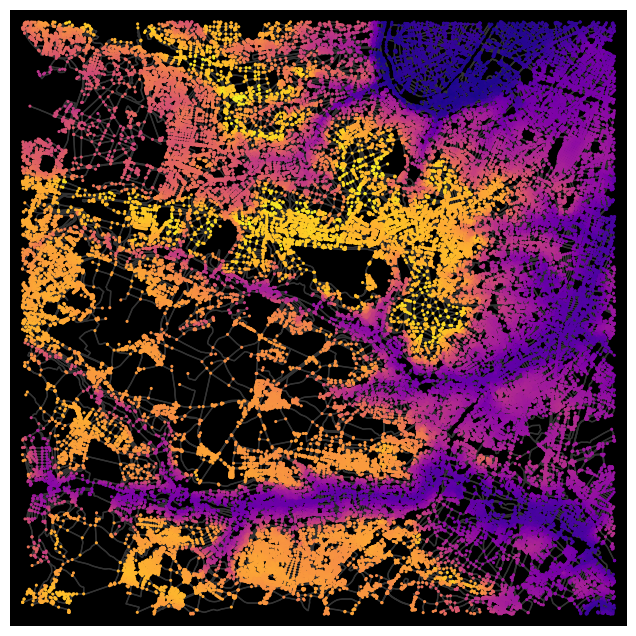

In [ ]:
# get one color for each node, by elevation, then plot the network
nc = ox.plot.get_node_colors_by_attr(G, "elevation", cmap="plasma")
fig, ax = ox.plot_graph(G, node_color=nc, node_size=5, edge_color="#333333", bgcolor="k")

## Plot the edges by grade

Grade is the ratio of elevation change to edge length. Plot edges colored from low/flat (violet) to high/steep (yellow).

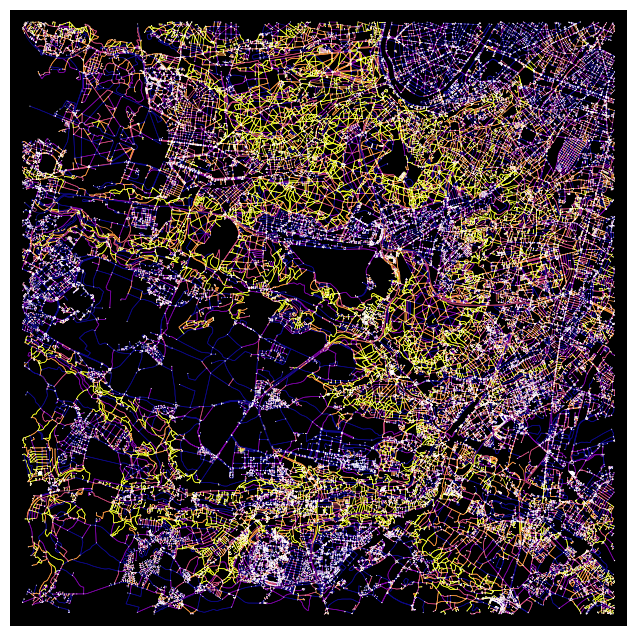

In [ ]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

In [ ]:
# select an origin and destination node (here the first and last) 
origin = list(G.nodes)[0]
destination = list(G.nodes)[-1]

In [ ]:
# define some edge impedance function here


def impedance(length, grade):
    penalty = grade**2
    return length * penalty


# add impedance and elevation rise values to each edge in the projected graph
# use absolute value of grade in impedance function if you want to avoid uphill and downhill
for _, _, _, data in G.edges(keys=True, data=True):           # in the (u, v, key, data) interator u, v, and key are not needed (replaced by  _)
    data["impedance"] = impedance(data["length"], data["grade_abs"])
    data["rise"] = data["length"] * data["grade"]

#### First find the shortest path that minimizes *trip distance*:

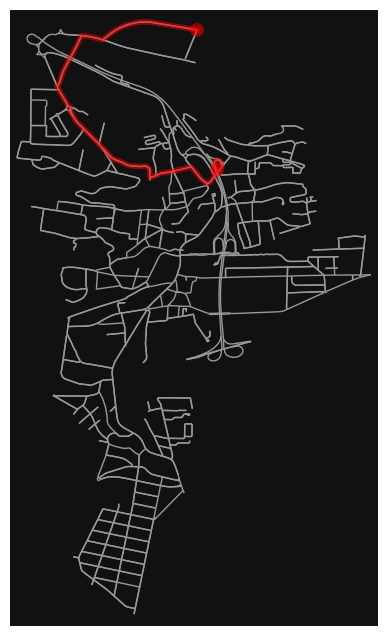

In [ ]:
route_by_length = ox.shortest_path(G, origin, destination, weight="length")
fig, ax = ox.plot_graph_route(G, route_by_length, node_size=0)

#### Now find the shortest path that avoids slopes by minimizing *impedance* (function of length and grade):

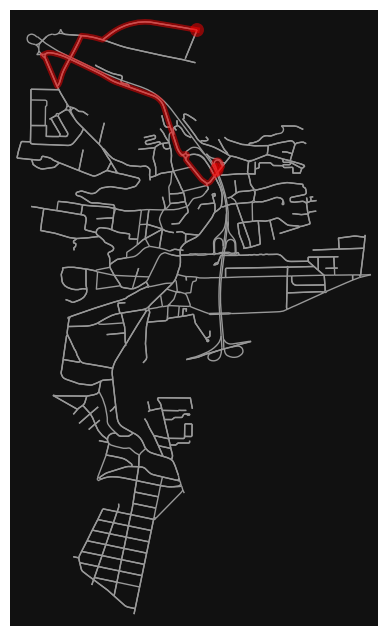

In [ ]:
route_by_impedance = ox.shortest_path(G, origin, destination, weight="impedance")
fig, ax = ox.plot_graph_route(G, route_by_impedance, node_size=0)

#### Print some summary stats about these two routes:

In [ ]:
def print_route_stats(route):
    route_grades = ox.routing.route_to_gdf(G, route, weight="grade_abs")["grade_abs"]
    msg = "The average grade is {:.1f}% and the max is {:.1f}%"
    print(msg.format(np.mean(route_grades) * 100, np.max(route_grades) * 100))

    route_rises = ox.routing.route_to_gdf(G, route, weight="rise")["rise"]
    ascent = np.sum([rise for rise in route_rises if rise >= 0])
    descent = np.sum([rise for rise in route_rises if rise < 0])
    msg = "Total elevation change is {:.1f} meters: {:.0f} meter ascent and {:.0f} meter descent"
    print(msg.format(np.sum(route_rises), ascent, abs(descent)))

    route_lengths = ox.routing.route_to_gdf(G, route, weight="length")["length"]
    print(f"Total trip distance: {np.sum(route_lengths):,.0f} meters")

In [ ]:
# stats of route minimizing length
print_route_stats(route_by_length)

# stats of route minimizing impedance (function of length and grade)
print_route_stats(route_by_impedance)

The average grade is 4.4% and the max is 24.8%
Total elevation change is 81.8 meters: 92 meter ascent and 11 meter descent
Total trip distance: 3,282 meters
The average grade is 2.9% and the max is 6.2%
Total elevation change is 81.8 meters: 89 meter ascent and 8 meter descent
Total trip distance: 3,726 meters


# Make a list of all slopes





In [14]:

# ==================================================
# Criteria for Defining a Climbing Road:
# ==================================================

# 1. Slope Threshold:
#    -------------------------------------------------
#    - Setting a minimum slope threshold (e.g., 1%): Ensure the road is consistently uphill, avoiding flat or downhill segments.

# 2. Boundary Conditions:
#    -------------------------------------------------
#    - Starting Point: The starting point should not be immediately adjacent to a lower (except if less than 1% slope) node, ensuring it is the beginning of the climb.
#    - Ending Point: The ending point should not connect to a higher (except if less than 1% slope) node, indicating the top of the climb.

# 3. Minimum Length:
#    -------------------------------------------------
#    - Length Requirement: Define a minimum length to ensure the climb is significant. This can be based on distance (100 m by default) and elevation (50 m by default).

# 4. Path Selection:
#    -------------------------------------------------
#    - Shortest Path: Consider the first few shortest paths (up to 5) between the same starting and ending points to capture different possible routes that meet the criteria without being exhaustive.
#    - Road Type: Differentiate between paved roads, trails, and other types of paths, as this might be relevant for specific applications. However, this differentiation is not done here.


import importlib
import graph_utils  # Import your module

# Reload the Strava_utils module to ensure it's the most up-to-date version
importlib.reload(graph_utils)
from graph_utils import *


# Parameteres for the slope to be find
threshold_slope = 0.02
min_length=100
min_elevation_gain=80

# Identify Potential Starting Nodes
potential_start_nodes = [node for node in G.nodes if is_potential_start_node(G, node, threshold_slope)]

# Main extraction of the climbing paths
valid_climbs = []

for start_node in potential_start_nodes:
    climbing_paths = get_climbing_paths(G, start_node, threshold_slope)
    valid_climbing_paths = filter_paths(G, climbing_paths, min_length, min_elevation_gain)

    valid_climbs.extend(valid_climbing_paths)


## PLot the result on a map or on Open Street Map

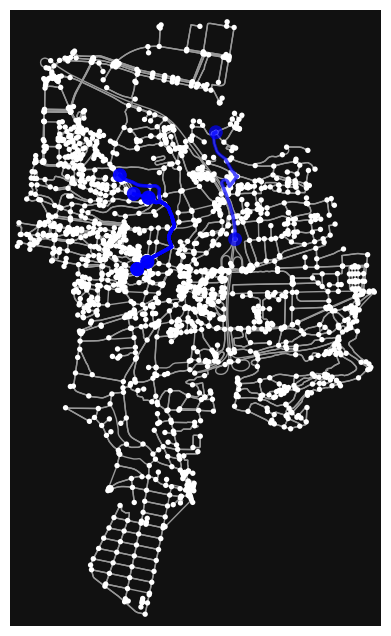

In [15]:
climbing_paths = [climb[0] for climb in valid_climbs]

# Create a list of linewidths for each route (all the same in this case)
route_linewidths = [2.5] * len(climbing_paths)

# Visualize the climbing paths using osmnx
fig, ax = ox.plot.plot_graph_routes(
    G, 
    climbing_paths, 
    route_colors='blue', 
    route_linewidths=route_linewidths, 
    route_alpha=0.7, 
    orig_dest_size=100
)

# Display the plot
plt.show()


# Show climbing roads with color depending on the slope on Open Strret Map
# climbing_paths = [climb[0] for climb in valid_climbs]
# map_with_climbs = display_paths_on_map(G, climbing_paths)
# map_with_climbs

### Save paths

In [ ]:

climbing_paths = [climb[0] for climb in valid_climbs]
gdf_paths_with_grades = convert_paths_to_gdf_with_grades(G, climbing_paths)

# Save to a GeoJSON file
save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.geojson', 'geojson')

# Save to a Shapefile
# save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.shp', 'shapefile')

# Save to a CSV file
# save_paths_to_file(gdf_paths_with_grades, 'climbing_paths.csv', 'csv')


## Import Strava HeatMap

Need cookies from account

In [ ]:
# import importlib
import Strava_utils  # Import your module

# If needed Reload the Strava_utils module to ensure it's the most up-to-date version
# importlib.reload(Strava_utils)

# Call the get_strava_cookies function from the Strava_utils module and capture the returned values
key_pair_id, policy, signature = Strava_utils.get_strava_cookies()

Using existing Strava keys from keys.py


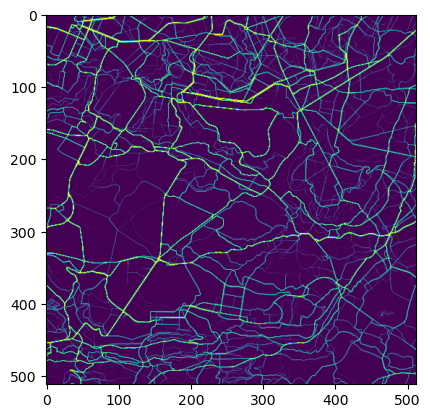

In [ ]:
import matplotlib.pyplot as plt
import folium

importlib.reload(Strava_utils)
from Strava_utils import *


location=[48.76, 2.17] # FOr Saclay


# Parameters for the Strava heatmap tile
activity = 'ride'  # Options: 'run', 'ride', 'winter', 'water', 'all'
color = 'blue'  # Options: 'blue', 'bluered', 'purple', 'hot', 'gray'
zoom_level = 11
nb_pixel = 512  # only 512 works; all other numbers give 256 pixels

# Convert the first coordinate of the route to tile coordinates
(xtile, ytile) = latlon_to_tile(location[0], location[1], zoom_level)

# URL template for the Strava heatmap tile
tile_url = f'https://heatmap-external-a.strava.com/tiles-auth/{activity}/{color}/{zoom_level}/{xtile}/{ytile}.png?px={nb_pixel}&'

# Download a tile with authentication
tile_image = download_tile(tile_url, key_pair_id, policy, signature)

# Display the tile image
plt.imshow(tile_image)
plt.show()


### Save Strava HeatMap in .PNG or .dat file

In [ ]:
from PIL import Image
import numpy as np
import io

output_dir = 'Strava_HeatMap_tiles'
os.makedirs(output_dir, exist_ok=True)
output_filename = f'{activity}_{color}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.png'
output_path = os.path.join(output_dir, output_filename)


# Save the tile image PNG
image = Image.fromarray(tile_image.astype(np.uint8))
image.save(output_path)

# Save the tile image as a 5matrix in a .dat file
matrix_output_path = os.path.join(output_dir, f'{activity}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.dat')
tile_image.astype(np.uint8).tofile(matrix_output_path)

# Save the tile image as a 512x512 matrix of ASCII numbers
matrix_output_path = f'{output_dir}/{activity}_{zoom_level}_{xtile}_{ytile}_{nb_pixel}px.dat'
np.savetxt(matrix_output_path, tile_image[:,:], fmt='%d')


### Calculate the popularity score of this road by averaging Strava HeatMap neighboring points along the road coordinates

In [ ]:

# Calculate the popularity score 
popularity_score = calculate_popularity_score(route_coords, tile_image, zoom_level,xtile, ytile)
print(f"Popularity Score: {popularity_score}")

NameError: name 'route_coords' is not defined

## Create a function that add this popularity score to edges of a graph

FOr now assuming the tiles_image of Strave HeatMap contains all edges !!!

In [ ]:
G = add_edge_popularity(G,tile_image, zoom_level,xtile, ytile)

# Print the graph edges with their attributes to verify
# for u, v, k, data in G.edges(keys=True, data=True):
#     print(f"Edge ({u}, {v}, {k}): {data}")


Added popularity attributes to all edges


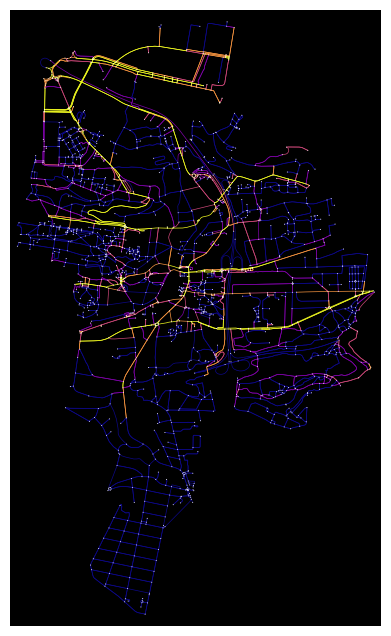

In [ ]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "popularity", cmap="plasma", num_bins=5, equal_size=False)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

## Save

In [ ]:
# ox.io.save_graphml(G, filepath='graph_with_popularity.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed

# ox.io.save_graphml(G, filepath='graph_with_popularity_Orsay.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed


import os
import datetime
import networkx as nx

# Function to generate a new filename with increment and timestamp
def generate_filename(base_name, extension):
    # Get current date and time
    now = datetime.datetime.now()
    timestamp = now.strftime('%Y%m%d_%H%M%S')

    # Initialize counter
    counter = 1
    while True:
        # Generate filename with counter and timestamp
        filename = f"{base_name}_{timestamp}_{counter}.{extension}"
        if not os.path.exists(filename):
            return filename
        counter += 1

# Function to convert attributes to supported types
def sanitize_attributes(G):
    for node, data in G.nodes(data=True):
        for key, value in data.items():
            if isinstance(value, (list, dict)):
                data[key] = str(value)
    
    for u, v, data in G.edges(data=True):
        for key, value in data.items():
            if isinstance(value, (list, dict)):
                data[key] = str(value)

# Example usage with your function
def save_graph_with_increment(G, base_name='graph_with_popularity', extension='graphml'):
    filepath = generate_filename(base_name, extension)
    sanitize_attributes(G)
    ox.io.save_graphml(G, filepath, gephi=False, encoding='utf-8')

# Save the graph with the new naming convention
save_graph_with_increment(G)


# NEW START Load existing graph

In [23]:

# G = ox.io.load_graphml('graph_with_popularity_Orsay.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_with_all_attributes_Orsay.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_Orsay_with_all_attributes_filtered.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_with_popularity.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

# G = ox.io.load_graphml('graph_with_all_attributes.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

G = ox.io.load_graphml('graph_with_all_attributes_filtered.graphml', node_dtypes=None, edge_dtypes=None, graph_dtypes=None)

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)                                                      # Go with GeoPandas GeoDataFrames
gps_x_min, gps_x_max = min(gdf_nodes['x'])+0.000001, max(gdf_nodes['x'])-0.000001
gps_y_min, gps_y_max = min(gdf_nodes['y'])+0.000001, max(gdf_nodes['y'])-0.000001
print(f'gps coord limits: [{gps_y_min} {gps_y_max}] [{gps_x_min} {gps_x_max}]')

gps coord limits: [48.687497099999995 48.819892100000004] [2.1055066 2.2876084999999997]


## remove not allowed path and keep only the path (for raod bike) for bike one from popularity

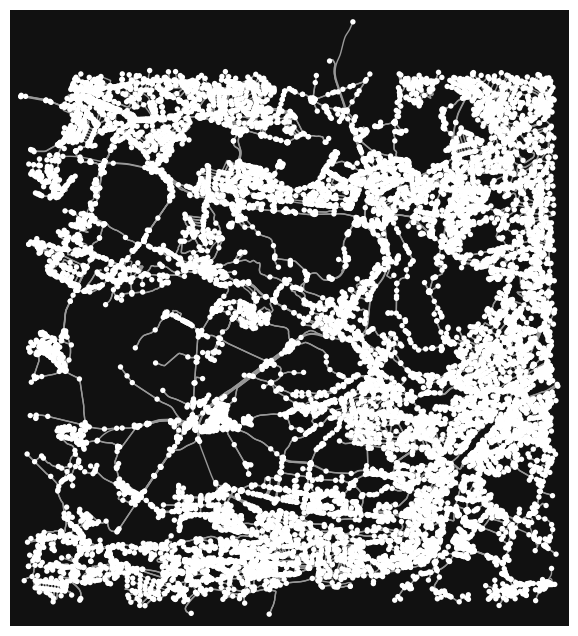

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [7]:
allowed_highway_types = [
    "motorway",
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "unclassified",
    "residential",
    "living_street",
    "service",
    "cycleway",
    "busway",
    "road",
    "unknown",
    "bus_guideway",
    "motorway_link",
    "trunk_link",
    "primary_link",
    "secondary_link",
    "tertiary_link"
]


def filter_by_highway_types(G, allowed_types):
    edges_to_remove = []
    for u, v, k, data in G.edges(keys=True, data=True):
        highway_type = data.get("highway")
        if isinstance(highway_type, list):
            # If highway is a list, check if any type in the list is allowed
            if not any(ht in allowed_types for ht in highway_type):
                edges_to_remove.append((u, v, k))
        else:
            if highway_type not in allowed_types:
                edges_to_remove.append((u, v, k))
    G.remove_edges_from(edges_to_remove)
    return G

def filter_by_popularity(G, min_popularity):
    edges_to_remove = []
    for u, v, k, data in G.edges(keys=True, data=True):
        popularity = float(data.get("popularity", 0))
        if popularity <= min_popularity:
            edges_to_remove.append((u, v, k))
    G.remove_edges_from(edges_to_remove)
    return G

min_popularity = 1

# Filter the graph by allowed highway types
G_filtered_highway = filter_by_highway_types(G, allowed_highway_types)

# Filter the graph by minimum popularity
G_filtered_popularity = filter_by_popularity(G_filtered_highway, min_popularity)

# Remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G_filtered_popularity)))

# Extract the largest weakly connected component
if not nx.is_weakly_connected(G):
    largest_wcc_nodes = max(nx.weakly_connected_components(G), key=len)
    G = G.subgraph(largest_wcc_nodes).copy()

# simplify the network (like Remove isolated nodes)
# G = ox.simplify_graph(G_filtered_final)
# G = ox.simplification.consolidate_intersections(G, tolerance=10, rebuild_graph=True, dead_ends=False, reconnect_edges=True)

# ox.io.save_graphml(G, filepath='graph_with_all_attributes_filtered.graphml', gephi=False, encoding='utf-8')    # save graph as map.graphml for later if needed

ox.plot_graph(G)


## Shows the graph in Open street map with color coded 
### Can be skiped to go after


In [ ]:
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Ensure the 'grade' and 'popularity' columns are present
if 'grade' not in edges_gdf.columns or 'popularity' not in edges_gdf.columns:
    raise ValueError("The graph edges do not contain 'grade' or 'popularity' attributes.")


# Convert 'grade' and 'popularity' columns to numeric, forcing errors to NaN
edges_gdf['grade'] = pd.to_numeric(edges_gdf['grade'], errors='coerce')
edges_gdf['popularity'] = pd.to_numeric(edges_gdf['popularity'], errors='coerce')

# Drop rows where 'grade' or 'popularity' could not be converted to numeric values
edges_gdf = edges_gdf.dropna(subset=['grade', 'popularity'])


# Filter edges 
# filtered_edges_gdf = edges_gdf[(edges_gdf['grade'] >= 0) & (edges_gdf['grade'] <= 0.2) & edges_gdf['popularity'] > 100]
filtered_edges_gdf = edges_gdf[(edges_gdf['grade'] >= 0) & (edges_gdf['grade'] <= 0.2)]


# Use the explore method to visualize the graph
# Color by 'grade' and add tooltips for 'grade' and 'popularity'
map = filtered_edges_gdf.explore(
    column='grade',               # Column to visualize
    cmap='inferno',               # Colormap for 'grade' 
    legend=True,                  # Show legend
    tooltip=['grade', 'popularity'], # Columns to show in the tooltip
    popup=True,                   # Show popups
    style_kwds=dict(weight=2),    # Line weight
    marker_kwds=dict(radius=6)    # Marker radius
)

''' 
viridis: Purple to yellow (sequential)
plasma: Dark blue to bright yellow (sequential)
magma: Dark purple to orange (sequential)
inferno: Dark purple to bright yellow (sequential)
cividis: Blue to yellow (sequential, color vision deficiency friendly)
'''

# Display the map
map

### Plot edge based on a given criteria such as popularity, travel_time, speed_kph, grade_abs, grade, length, maxspeed

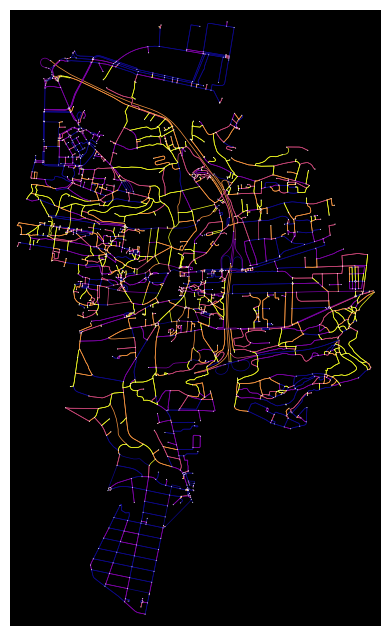

In [ ]:
# get a color for each edge, by grade, then plot the network
ec = ox.plot.get_edge_colors_by_attr(G, "grade_abs", cmap="plasma", num_bins=5, equal_size=True)
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=0.5, node_size=0.5, bgcolor="k")

In [ ]:
ox.plot.plot_figure_ground(G, color='w')

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np

# Load your graph (example with a predefined graph)
# G = ox.graph_from_place("Piedmont, California, USA", network_type="drive")

# Parameters
color_attr = "grade_abs"
color_cmap = "plasma"
color_num_bins = 5
color_equal_size = True

opacity_attr = "popularity"
opacity_min = 0.3
opacity_max = 1.0

figsize = (100, 100)
bgcolor = "k"
node_color = "r"
node_size = 0
show = True
save = True
filepath = "graph_plot.png"
dpi = 300
bbox = None

# Define street widths based on highway types
street_widths = {
    "motorway": 4,
    "trunk": 3,
    "primary": 2.5,
    "secondary": 2,
    "tertiary": 1.5,
    "residential": 1,
    "service": 0.5,
    'unclassified': 0.5
}

def get_street_width(d, default_width=1):
    highway = d.get('highway')
    if isinstance(highway, list):  # In case 'highway' is a list, take the first element
        highway = highway[0]
    return street_widths.get(highway, default_width)

def get_numeric_attribute_values(G, attribute):
    values = []
    for u, v, k, d in G.edges(keys=True, data=True):
        try:
            value = float(d[attribute])
        except (ValueError, TypeError):
            value = np.nan
        values.append(value)
    return values

# Get edge colors based on color attribute
edge_colors = ox.plot.get_edge_colors_by_attr(G, color_attr, cmap=color_cmap, num_bins=color_num_bins, equal_size=color_equal_size)

# Get edge linewidths based on street types (highway attribute)
linewidths = [get_street_width(d) for u, v, k, d in G.edges(keys=True, data=True)]

# Add street_width values to each edge in the graph
for _, _, _, data in G.edges(keys=True, data=True):
    data["street_width"] = get_street_width(data)

# Get edge opacities based on opacity attribute
opacities = []
attr_values = get_numeric_attribute_values(G, opacity_attr)
attr_min = np.nanmin(attr_values)
attr_max = np.nanmax(attr_values)
for value in attr_values:
    if np.isnan(value):
        opacities.append(opacity_min)
    else:
        normalized_value = (value - attr_min) / (attr_max - attr_min)
        opacities.append(opacity_min + normalized_value * (opacity_max - opacity_min))


# Plot the graph
fig, ax = ox.plot_graph(
    G,
    figsize=figsize,
    bgcolor=bgcolor,
    node_color=node_color,
    node_size=node_size,
    node_alpha=None,
    node_edgecolor="none",
    node_zorder=1,
    edge_color=edge_colors,
    edge_linewidth=linewidths,
    edge_alpha=opacities,
    show=False,
    close=False,
    save=False,
    filepath=None,
    dpi=dpi,
    bbox=bbox
)

# Add colorbar if color_attr is used
sm = plt.cm.ScalarMappable(cmap=color_cmap, norm=plt.Normalize(
    vmin=np.nanmin([d[color_attr] for u, v, k, d in G.edges(keys=True, data=True) if color_attr in d and d[color_attr] is not None]), 
    vmax=np.nanmax([d[color_attr] for u, v, k, d in G.edges(keys=True, data=True) if color_attr in d and d[color_attr] is not None])))
sm._A = []  # For the scalar mappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(color_attr)

# Save and/or show the plot
if save and filepath:
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')

if show:
    plt.show()

plt.close(fig)


# Calculate shortest paths, considering grade impedance

May be consider or test OSMnx + igraph for faster performance

### Add attributes to edges (street_width, elevation, ...). TO BE PUT BEFORE AND GROUP

In [5]:


street_widths = {
    "motorway": 4,
    "trunk": 3,
    "primary": 2.5,
    "secondary": 2,
    "tertiary": 1.5,
    "residential": 1,
    "service": 0.5,
    'unclassified': 0.5
}

def get_street_width(d, default_width=1):
    highway = d.get('highway')
    if isinstance(highway, list):  # In case 'highway' is a list, take the first element
        highway = highway[0]
    return street_widths.get(highway, default_width)


# Add street_width values to each edge in the graph
for _, _, _, data in G.edges(keys=True, data=True):
    data["street_width"] = get_street_width(data)
    

# Add height agin (d+ if >0 d- if <0) values to each edge in the graph
def add_height_gain_to_edges(G):
    for u, v, _, d in G.edges(keys=True, data=True):
        elevation_u = G.nodes[u].get('elevation', np.nan)
        elevation_v = G.nodes[v].get('elevation', np.nan)
        d['height_gain'] = elevation_v - elevation_u
    return G


G = add_height_gain_to_edges(G)


ox.io.save_graphml(G, filepath='graph_with_all_attributes.graphml', gephi=False, encoding='utf-8') 



### Choose origin to optimize

In [24]:
# select an origin and destination node (here the first and last) 
# origin = list(G.nodes)[2]
# destination = list(G.nodes)[223]

origin_x, origin_y = (2.2400589417726926,48.707680229382355) # Palaiseau
destination_x, destination_y = (2.0744209900739583,48.706562842057394) # St Remy

origin = ox.nearest_nodes(G, origin_x, origin_y)
destination = ox.nearest_nodes(G, destination_x, destination_y)


## Calculation of the cost function. To be improved:

* Linear combinaition with weight
* Polynomial Combination
Exponential Combination
Logarithmic Combination
Rational Function Combination
Weighted Harmonic Mean
Generalized Mean (Power Mean)
Custom Functions

In [25]:
# Define weights for each criterion in a dictionary
weights = {
    # "length": 1.0,
    # grade_abs": 1.0,
    "popularity": 0.3,
    "street_width": 0.2,
    "height_gain": 1.0,
    # Add more criteria here with their weights
}

# Normalize function
def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value) if max_value != min_value else 0


# Define a general impedance function
def impedance(data, criteria, weights, mins, maxs):
    impedance_value = 0
    for criterion in criteria:
        value = float(data.get(criterion, 0))  # Convert to float
        normalized_value = normalize(value, mins[criterion], maxs[criterion])
        impedance_value += weights[criterion] * normalized_value
    return impedance_value

# Calculate min and max values for normalization
criteria = list(weights.keys())
mins = {criterion: min(float(d[criterion]) for _, _, _, d in G.edges(keys=True, data=True) if criterion in d) for criterion in criteria}
maxs = {criterion: max(float(d[criterion]) for _, _, _, d in G.edges(keys=True, data=True) if criterion in d) for criterion in criteria}

# Add impedance values to each edge in the graph
# for _, _, _, data in G.edges(keys=True, data=True):
#    data["impedance"] = impedance(data, criteria, weights, mins, maxs)

'''
# Add hoc impedance
for _, _, _, data in G.edges(keys=True, data=True):
    d_plus = float(data["height_gain"])
    if d_plus > 0:
        # data["impedance"] = 1/(20 + d_plus)
        data["impedance"] = (20 + d_plus)/(1+d_plus * d_plus)
    else:
        data["impedance"] = 0   
'''

# Add hoc impedance
for _, _, _, data in G.edges(keys=True, data=True):
    d_plus = float(data["height_gain"])
    if d_plus > 0:
        # data["impedance"] = 1/(20 + d_plus)
        data["impedance"] = 1/(float(data["length"]) * d_plus * (float(data['popularity'])+2) )
        # data["impedance"] = 1/(data["length"] * d_plus )
    else:
        data["impedance"] = 10 

In [17]:
# how many CPUs do you have
nb_cpus = mp.cpu_count()

import time

# Start the timer
start_time = time.time()



# Example: Find the shortest path based on impedance
# origin = ox.nearest_nodes(G, X=origin_x, Y=origin_y)
# destination = ox.nearest_nodes(G, X=destination_x, Y=destination_y)

# 0.1 s 
shortest_path = nx.shortest_path(G, origin, destination, weight='impedance')

# 0.62 s for cpus=1
# shortest_path = ox.distance.shortest_path(G, origin, destination, weight='impedance', cpus=1)

# 0.48 s for cpus= nb_cpus
# shortest_path = ox.distance.shortest_path(G, origin, destination, weight='impedance', cpus=nb_cpus)

''' may be use and tst usig several chips etc.. 

ox.shortest_path(G, origin, destination, weight="impedance")
'''



# End the timer
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time} seconds")


Execution time: 0.029142379760742188 seconds


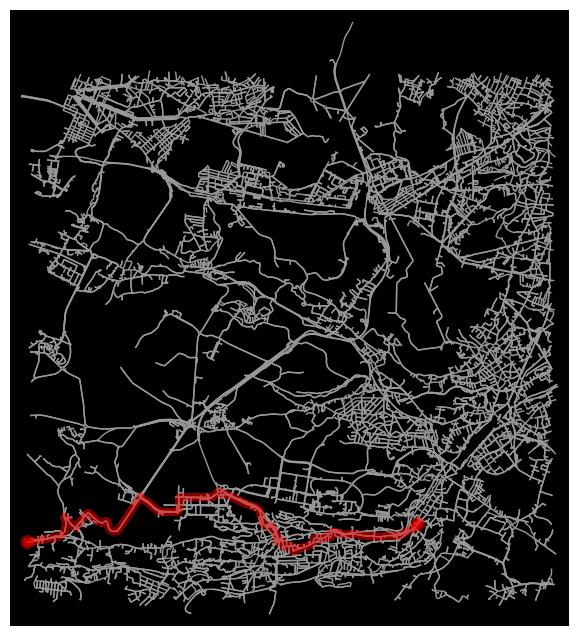

In [26]:

# Plot the shortest path
fig, ax = ox.plot_graph_route(G, shortest_path, route_linewidth=6, node_size=0, bgcolor='k')

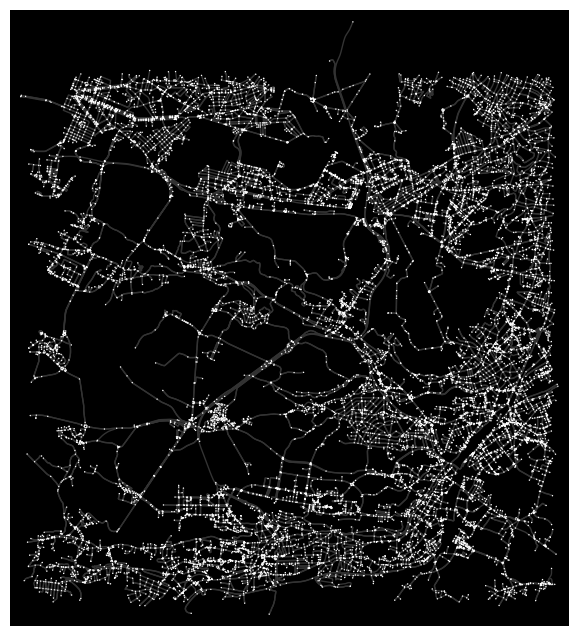

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [35]:
ox.plot_graph(G, node_size=1, edge_color="#333333", bgcolor="k")

In [27]:
import importlib
import graph_utils

# Reload the module to ensure the latest version is used
importlib.reload(graph_utils)

from graph_utils import *  # our function


get_d_plus_total(G,shortest_path)

161.29200000000006

# Bayesian optimization to find cycling routes that fit our needs

#### maximize d+ / 30 kms / do not go on the same route twice / (avoiding road with lot of vehicules)

In [28]:
!pip install scikit-optimize
from skopt import gp_minimize, gbrt_minimize, load
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args, cook_initial_point_generator
from skopt.callbacks import CheckpointSaver

In [36]:

our_spot = (48.707680229382355,2.2400589417726926) # Palaiseau

our_spot = (48.805589, 2.259308) # Issy


starting_spot = our_spot      # (y, x)
waypoints = random_gps_waypoints(3, gps_y_min, gps_y_max, gps_x_min, gps_x_max)           # run this if you want to get random waypoints

route2, gdf_nodes_route2, rt_lst = generate_loop(G, gdf_nodes, gdf_edges, starting_spot, waypoints)     # main function to create the route

loss = get_loss(route2, gdf_nodes_route2, kms_target=50, verbose=True)


--------- loss: 13.03 ------ loss kms: 0.00 (54.21), d+: 9.33 (581.1379999999995), twice_penalty: 3.71 ------


In [ ]:
# Plot elevation profil
gdf_nodes_route2.plot(kind='scatter', x="cum_dist", y="elevation", marker='.', figsize=(20,4))

# explore a route interactively
route_edges = ox.routing.route_to_gdf(G, route2, weight="length")
route_edges.explore(tiles="OpenStreetMap", style_kwds={"weight": 5})

## Start optimization

In [38]:
# target optimization (1. kms, 2. d+ max)
kms_target = 80

def loss_function(x):
    """ x is a list or value for parameters to test (see space variable below) """
    # waypoints = [(x[0], x[1]), (x[2], x[3])]
    waypoints = []
    for i in range(int(len(x)/2)):
        waypoints.append((x[i*2], x[(i*2)+1]))
    print(f'waypoints: {waypoints}')
    route, gdf_nodes_route, _ = generate_loop(G, gdf_nodes, gdf_edges, our_spot, waypoints)
    
    if route == -1:
        return 100
    else:
        loss = get_loss(route, gdf_nodes_route, kms_target=kms_target, verbose=True)
    return loss 


def optimizer(res):
    """ optimizer callback called when new try of minimize. return True for early stop """
    # print(f'Bayesian Optim - {res.x}, loss: {res.fun:.4f}')
    if res.fun < 5:       # early stoping
        return True

In [39]:
checkpoint_saver = CheckpointSaver("./checkpoint.pkl", compress=9) # keyword arguments will be passed to `skopt.dump

In [40]:
# number of wavepoints
nb_wp = 7

space = []
for i in range(nb_wp):
    space.append(Real(gps_y_min, gps_y_max, name=f'wp_{i+1}y'))
    space.append(Real(gps_x_min, gps_x_max, name=f'wp_{i+1}x'))

In [41]:
# restore previous results using checkpoint.pkl if it exist
if os.path.isfile('./checkpoint.pkl'):
  opt_res = load('./checkpoint.pkl')  

In [42]:
nb_points = 100  # one run takes typically 20 seconds, before the value was 250
nb_runs = round(nb_points * 1.5 + 5) #  before the value was 300

opt_res = gp_minimize(loss_function, space, n_calls=nb_runs, n_jobs=-1, kappa=50, n_initial_points=nb_points,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

Iteration No: 1 started. Evaluating function at random point.
waypoints: [(48.69429462798273, 2.226821565173189), (48.72251935152399, 2.13149977547236), (48.761499038066795, 2.224336888438955), (48.81025996382487, 2.1811576909103283), (48.792338588948134, 2.1663131742271373), (48.81096479233306, 2.1671573637805714), (48.737556770424355, 2.17278620563869)]
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 3.7075
Function value obtained: 100.0000
Current minimum: 100.0000
Iteration No: 2 started. Evaluating function at random point.
waypoints: [(48.74326234917621, 2.231584566550694), (48.80678254599295, 2.1503890912093535), (48.801304164433795, 2.11628344615631), (48.79716176024811, 2.10587072137482), (48.75787230017619, 2.195395081981263), (48.801376471398854, 2.2208287867093444), (48.80586593434774, 2.125621673347703)]
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 2.4157
Function value obtained: 100.0000
Current minimum: 100.0000
Iteration No: 3 

In [43]:
opt_res = gp_minimize(loss_function, space, n_calls=nb_runs//10 + 1, n_jobs=-1, kappa=10, n_initial_points=1, x0=opt_res.x_iters, y0=opt_res.func_vals,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

opt_res = gp_minimize(loss_function, space, n_calls=nb_runs//30 + 1, n_jobs=-1, kappa=1.5, n_initial_points=1, x0=opt_res.x_iters, y0=opt_res.func_vals,
    initial_point_generator=cook_initial_point_generator("lhs", criterion="maximin"), random_state=1337,
    callback=[optimizer, checkpoint_saver], verbose=True)     # x0=res.x_iters, y0=res.func_vals, kappa=1.96

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0397
Function value obtained: 14.2969
Current minimum: 11.9546
Iteration No: 2 started. Searching for the next optimal point.
waypoints: [(48.75116783558295, 2.1204066470618934), (48.7228477135163, 2.229143295327422), (48.724164022670195, 2.2402302605210225), (48.803239505652876, 2.199694515824595), (48.691426950701604, 2.1826501895882573), (48.768497861895206, 2.1755980188309954), (48.81111094069992, 2.1682828810976202)]
Iteration No: 2 ended. Search finished for the next optimal point.
Time taken: 22.4550
Function value obtained: 100.0000
Current minimum: 11.9546
Iteration No: 3 started. Searching for the next optimal point.
waypoints: [(48.81170483060694, 2.1492098339390484), (48.77279390935455, 2.233039275902314), (48.781098353333874, 2.1550930626702534), (48.81812434827703, 2.235908120161147), (48.80092011816376, 2.2625494271509003), (48.7468243645093

In [ ]:
# rebuild best route found
best_wp = []
for i in range(int(len(opt_res.x)/2)):
    best_wp.append((opt_res.x[i*2], opt_res.x[(i*2)+1]))

best_route, best_gdf_nodes_route, rt_lst = generate_loop(G, gdf_nodes, gdf_edges, our_spot, best_wp)


loss = get_loss(best_route, best_gdf_nodes_route, kms_target=kms_target, verbose=True)


# explore a route interactively
route_edges = ox.routing.route_to_gdf(G, best_route, weight="length")
route_edges.explore(tiles="OpenStreetMap", style_kwds={"weight": 5})


<Axes: xlabel='cum_dist', ylabel='elevation'>

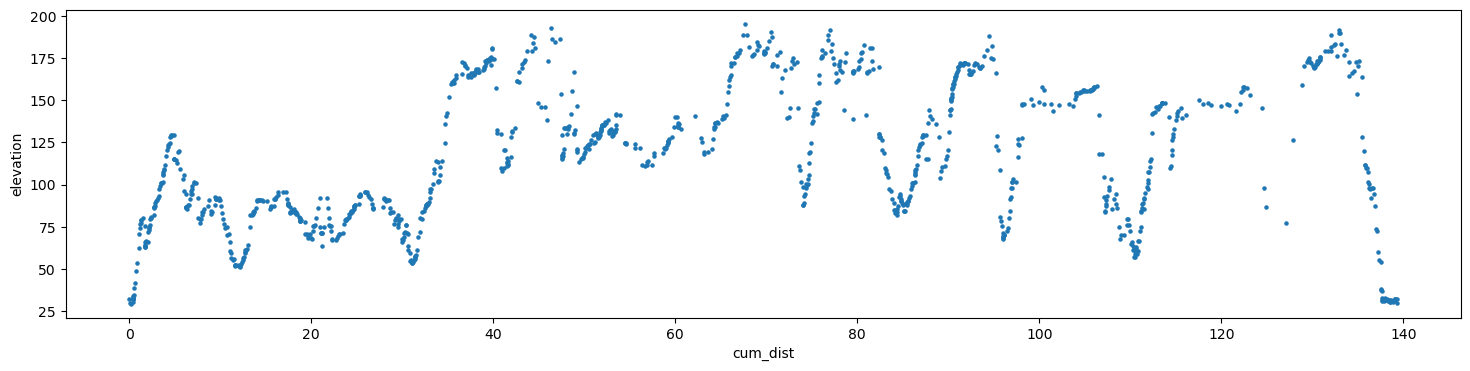

In [110]:

# plot Profile
best_gdf_nodes_route.plot(kind='scatter', x="cum_dist", y="elevation", marker='.', figsize=(18,4))



In [112]:
from datetime import datetime
import geopandas as gpd
from gpx_formatter import TEMPLATE, TRACE_POINT

def convert_gdf_to_gpx(gdf, name):
    trace_points = "\n".join([
        TRACE_POINT.format(
            lat=row['y'],
            lon=row['x'],
            elevation=row['elevation'],
            timestamp=datetime.now().isoformat()
        ) for idx, row in gdf.iterrows()
    ])

    gpx_payload = TEMPLATE.format(
        name=name,
        timestamp=datetime.now().isoformat(),
        trace_points=trace_points
    )

    return gpx_payload

# Example usage with your GeoDataFrame
gpx_data = convert_gdf_to_gpx(best_gdf_nodes_route, "My Route")

with open("my_new_route_1950d+_140k.gpx", "w") as f:
    f.write(gpx_data)


In [ ]:

plt.figure(); plot_objective(opt_res);

# Clear linear relations between x and x+1
plot = plot_convergence(("result", opt_res), yscale="log")